# HAR testing

In [5]:
# Standard library imports
import sys
from collections import defaultdict

import numpy as np
import pandas as pd

# Project-specific imports
sys.path.append('../src/')
from models.types import ModelConfig
from models.har import HARModel

data_path = '../data/processed/HAR/'
coin = 'BTC'
daily_base = pd.read_parquet(data_path + f'{coin}_har.parquet')

# Try if GPU is available, else fallback to CPU
device = 'cuda' if True else 'cpu'

def rolling_har_experiment(
    data,
    n_data_list,
    val_window=100,
    step=7,
    test_ratio=0.20,
    config=None
):

    results = defaultdict(list)

    # Chronological split
    split_idx = int(len(data) * (1 - test_ratio))
    trainval_data = data[:split_idx]
    test_data = data[split_idx:]

    for n_data in n_data_list:

        print(f'\nRunning n_data = {n_data}')

        val_losses = []

        start = 0
        end = n_data

        while end + val_window <= len(trainval_data):

            train_slice = trainval_data[start:end]
            val_slice = trainval_data[end:end+val_window]

            X_train = train_slice[config.features]
            y_train = train_slice['target']
            X_val = val_slice[config.features]
            y_val = val_slice['target']

            model = HARModel(config)
            fit_res = model.fit(X_train, y_train, X_val, y_val)

            if fit_res.val_loss is not None:
                val_losses.append(fit_res.val_loss)

            start += step
            end += step

        results['n_data'].append(n_data)
        results['val_qlike_mean'].append(np.mean(val_losses) if len(val_losses) > 0 else np.nan)

    results_df = pd.DataFrame(results).dropna()

    # Select best by QLIKE (lower is better)
    best_n = int(results_df.sort_values('val_qlike_mean').iloc[0]['n_data'])

    print('\nBest n_data selected:', best_n)

    return results_df, best_n, test_data

n_data_list = np.arange(64, 513, 16)

config = ModelConfig(
    name='HAR_baseline',
    device=device,
    lookback_days=30,
    features=['RV_d', 'RV_w', 'RV_m']
)

results_df, best_n, test_data = rolling_har_experiment(
    daily_base,
    n_data_list,
    val_window=100,
    step=7,
    test_ratio=0.20,
    config=config
)
results_df


Running n_data = 64

Running n_data = 80

Running n_data = 96

Running n_data = 112

Running n_data = 128

Running n_data = 144

Running n_data = 160

Running n_data = 176

Running n_data = 192

Running n_data = 208

Running n_data = 224

Running n_data = 240

Running n_data = 256

Running n_data = 272

Running n_data = 288

Running n_data = 304

Running n_data = 320

Running n_data = 336

Running n_data = 352

Running n_data = 368

Running n_data = 384

Running n_data = 400

Running n_data = 416

Running n_data = 432

Running n_data = 448

Running n_data = 464

Running n_data = 480

Running n_data = 496

Running n_data = 512

Best n_data selected: 288


,n_data,val_qlike_mean
0,64,1.762043e+07
1,80,1.018279e+07
2,96,1.018671e+07
3,112,5.325128e+06
4,128,4.502587e+06
5,144,4.185322e+06
6,160,3.062550e+06
7,176,1.153315e+06
8,192,4.092092e-01
9,208,4.192153e-01


In [4]:
def test_evaluation(test_data, best_n, step, config):

    test_losses = []
    test_preds = []
    beta_used = []
    fit_train_losses = []
    fit_loss_names = []

    start = 0
    end = best_n

    while end < len(test_data):

        train_slice = test_data[start:end]
        test_point = test_data[end:end+1]

        X_train = train_slice[config.features]
        y_train = train_slice['target']
        X_test = test_point[config.features]
        y_test = test_point['target']

        model = HARModel(config)
        fit_result = model.fit(X_train, y_train)

        beta_used.append(fit_result.fitted_params['beta'])
        fit_train_losses.append(fit_result.train_loss)
        fit_loss_names.append(fit_result.loss_name)

        y_hat = model.predict(X_test)
        mse = model.mse(y_test, y_hat)

        test_losses.append(mse)
        test_preds.append(y_hat.item())

        start += step
        end += step

    diagnostics = pd.DataFrame({
        'fit_loss_name': fit_loss_names,
        'fit_train_loss': fit_train_losses
    })

    return np.array(test_losses), np.array(test_preds), np.array(beta_used), diagnostics

test_losses, test_preds, beta_used, diagnostics = test_evaluation(
    test_data,
    best_n,
    step=7,
    config=config
)
diagnostics.head()

,fit_loss_name,fit_train_loss


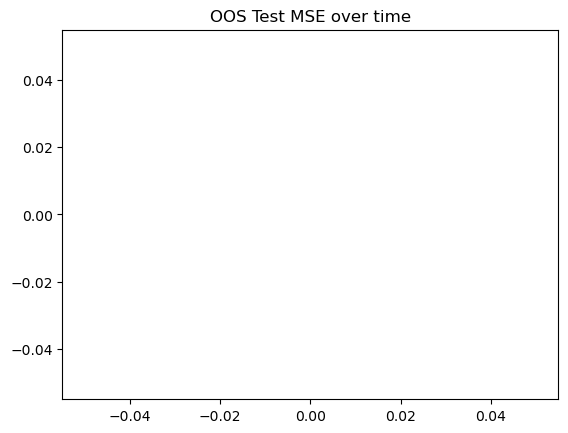

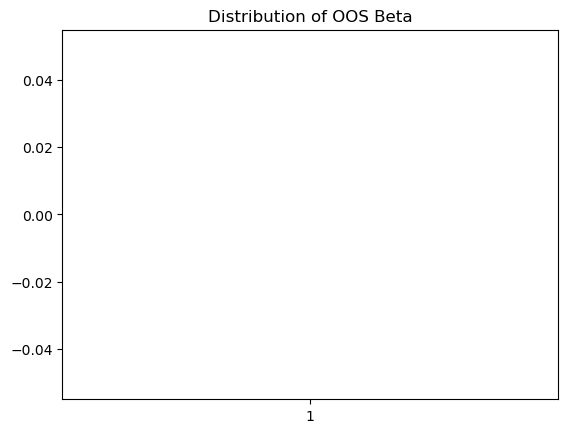

In [3]:
import matplotlib.pyplot as plt

plt.plot(test_losses)
plt.title("OOS Test MSE over time")
plt.show()

plt.boxplot(beta_used)
plt.title("Distribution of OOS Beta")
plt.show()